# Assignment 4 — Residual Analysis & Model Diagnostics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
residuals = y_test - y_pred

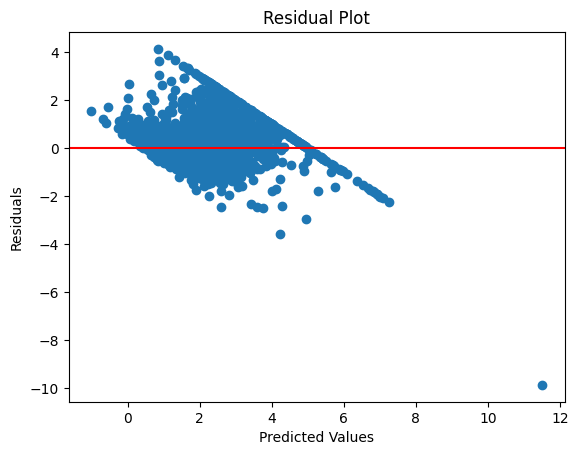

In [6]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

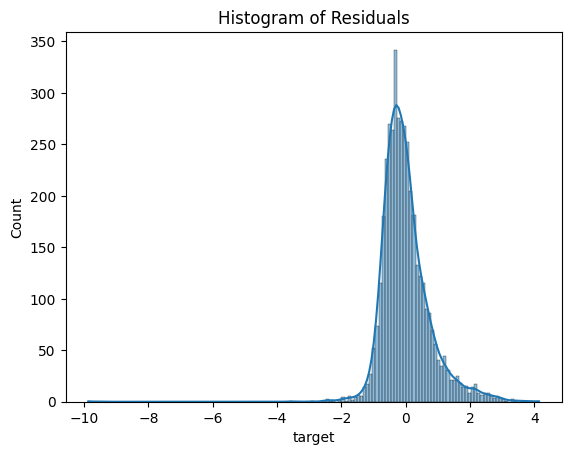

In [7]:
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

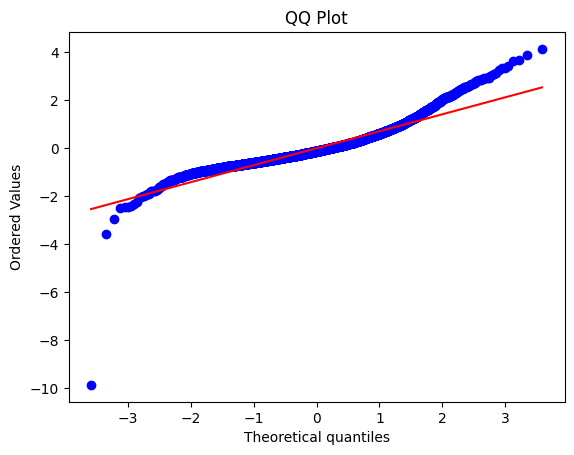

In [8]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

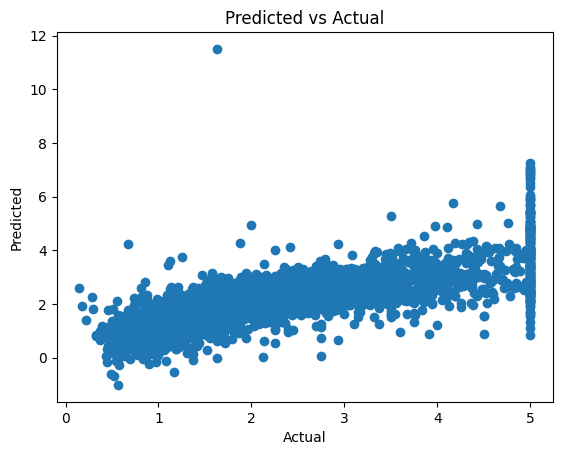

In [9]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [10]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

Durbin-Watson: 2.040741738727077


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.7455813830127761
R2: 0.5757877060324511


## Residual Analysis & Model Diagnostics

### 1. Linearity
- Residual plot shows random scatter around zero.
- No clear pattern → Linear relationship is reasonably satisfied.

---

### 2. Normality of Residuals
- Histogram is approximately bell-shaped.
- QQ plot points lie close to diagonal.
- Residuals are approximately normally distributed.

---

### 3. Homoscedasticity
- Residual plot shows roughly constant spread.
- No funnel shape → Homoscedasticity mostly satisfied.

---

### 4. Independence of Errors
- Durbin-Watson value is close to 2.
- Indicates no strong autocorrelation.

---

## Questions

### Q1. Are residuals normally distributed?
Yes, approximately normal based on histogram and QQ plot.

---

### Q2. Is there heteroscedasticity?
No strong evidence. Residual spread appears constant.

---

### Q3. How to fix violations?

If violations occur:

- Non-linearity:
  - Add polynomial features
  - Use non-linear models

- Non-normal residuals:
  - Apply log transformation on target

- Heteroscedasticity:
  - Use weighted regression
  - Transform features

- Autocorrelation:
  - Use time-series models (ARIMA)

---

## Conclusion
Linear Regression assumptions are reasonably satisfied, and the model is valid for this dataset.